# Final_7 + Final_9 앙상블 (학습 없음, 예측만)

두 모델의 test softmax를 평균. 서로 다른 학습 방식이라 다양성 효과 기대.
- Final_7: V2+Archive 동시 학습 (LB 0.554)
- Final_9: Archive 사전학습 → V2 fine-tuning (LB 0.548)

체크포인트가 outputs/checkpoints_final7, checkpoints_final9 에 있어야 함.


In [1]:
import numpy as np, pandas as pd, torch, gc
import torch.nn.functional as F
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
import timm
from PIL import Image
import torchvision.transforms as T
import warnings; warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

V2_ROOT = Path(r"C:\\Users\\USER\\Desktop\\대학\\3학년 1학기\\머신러닝 및 실습\\캐글 알츠하이머 - 개인\\alzheimer-prediction")
V2_TEST_DIR = V2_ROOT / "test"
V2_SUB_CSV = V2_ROOT / "sample_submission.csv"
OUTPUT_DIR = Path("./outputs")
CKPT7 = OUTPUT_DIR / "checkpoints_final7"
CKPT9 = OUTPUT_DIR / "checkpoints_final9"

LABEL2IDX = {'MildDemented':0,'ModerateDemented':1,'NonDemented':2,'VeryMildDemented':3}
IDX2LABEL = {v:k for k,v in LABEL2IDX.items()}
NUM_CLASSES=4; SLICES_PER_PATIENT=61; IMG_SIZE=224; BATCH_SIZE=64; NUM_WORKERS=0
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
MODEL_NAME='convnext_tiny'; DROP_RATE=0.4; DROP_PATH_RATE=0.3


cuda


In [2]:
def get_patient_id(fn):
    n=int(fn.replace('test_','').replace('.jpg','')); return (n-1)//SLICES_PER_PATIENT
def get_slice_idx(fn):
    n=int(fn.replace('test_','').replace('.jpg','')); return (n-1)%SLICES_PER_PATIENT

sub_df = pd.read_csv(V2_SUB_CSV)
sub_df['patient_id']=sub_df['filename'].apply(get_patient_id)
sub_df['slice_idx']=sub_df['filename'].apply(get_slice_idx)
print(len(sub_df))

class V2Dataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df=df.reset_index(drop=True); self.img_dir=Path(img_dir); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img=Image.open(self.img_dir/self.df.iloc[idx]['filename']).convert('RGB')
        return self.transform(img)

def tta_orig(): return T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.ToTensor(),T.Normalize(MEAN,STD)])
def tta_flip(): return T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.RandomHorizontalFlip(p=1.0),T.ToTensor(),T.Normalize(MEAN,STD)])
def tta_rot(): return T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.RandomAffine(degrees=(5,5),translate=(0,0),scale=(1.0,1.0)),T.ToTensor(),T.Normalize(MEAN,STD)])

def build_model():
    return timm.create_model(MODEL_NAME,pretrained=False,num_classes=NUM_CLASSES,
                             drop_rate=DROP_RATE,drop_path_rate=DROP_PATH_RATE).to(device)

@torch.no_grad()
def predict_logits(model, loader):
    model.eval(); A=[]
    for imgs in loader:
        imgs=imgs.to(device,non_blocking=True)
        with autocast(): L=model(imgs)
        A.append(L.float().cpu().numpy())
    return np.concatenate(A,0)


17629


In [3]:
# 두 모델 폴더 각각 예측해서 softmax 합산
tta_list=[tta_orig(),tta_flip(),tta_rot()]
test_loaders=[DataLoader(V2Dataset(sub_df,V2_TEST_DIR,t),batch_size=BATCH_SIZE*2,
              shuffle=False,num_workers=NUM_WORKERS,pin_memory=True) for t in tta_list]

def predict_model_dir(ckpt_dir):
    sm_sum=np.zeros((len(sub_df),NUM_CLASSES),dtype=np.float32); n=0
    for fi in range(4):
        p=ckpt_dir/f"fold{fi}_best.pt"
        if not p.exists():
            print(f"  MISSING {p}"); continue
        model=build_model()
        model.load_state_dict(torch.load(p,map_location=device))
        for ld in test_loaders:
            L=predict_logits(model,ld)
            sm_sum+=F.softmax(torch.from_numpy(L),dim=1).numpy(); n+=1
        del model; torch.cuda.empty_cache(); gc.collect()
        print(f"  fold{fi} done")
    return sm_sum/n

print("=== Final_7 예측 ===")
sm7=predict_model_dir(CKPT7)
print("=== Final_9 예측 ===")
sm9=predict_model_dir(CKPT9)


=== Final_7 예측 ===
  fold0 done
  fold1 done
  fold2 done
  fold3 done
=== Final_9 예측 ===
  fold0 done
  fold1 done
  fold2 done
  fold3 done


In [4]:
# 앙상블 (단순 평균)
test_sm=(sm7+sm9)/2.0
print("ensemble slice dist:", Counter(test_sm.argmax(1)))

def slice_weight(s): return 1.5 if 15<=s<=45 else 1.0
sample_sub=pd.read_csv(V2_SUB_CSV)

# slice argmax (Final_7에서 최고였던 방식)
sl=[IDX2LABEL[i] for i in test_sm.argmax(1)]
sub_slice=pd.DataFrame({'filename':sub_df['filename'],'label':sl})
sub_slice=sample_sub[['filename']].merge(sub_slice,on='filename',how='left')
sub_slice.to_csv(OUTPUT_DIR/"submission_ens79_slice_argmax.csv",index=False)
print("saved slice_argmax:", dict(sub_slice['label'].value_counts()))

# patient soft vote
tp=sub_df.copy()
for c in range(NUM_CLASSES): tp[f'p{c}']=test_sm[:,c]
tp['w']=tp['slice_idx'].apply(slice_weight)
for c in range(NUM_CLASSES): tp[f'wp{c}']=tp[f'p{c}']*tp['w']
cols=[f'wp{c}' for c in range(NUM_CLASSES)]
pat_p=tp.groupby('patient_id')[cols].sum()
pat_w=tp.groupby('patient_id')['w'].sum()
pat_p=pat_p.div(pat_w,axis=0)
pat_label=pat_p.values.argmax(1)
pid2lbl=dict(zip(pat_p.index,pat_label))
tp['final']=tp['patient_id'].map(pid2lbl); tp['label']=tp['final'].map(IDX2LABEL)
sub_pat=sample_sub[['filename']].merge(tp[['filename','label']],on='filename',how='left')
sub_pat.to_csv(OUTPUT_DIR/"submission_ens79_patient_argmax.csv",index=False)
print("saved patient_argmax:", dict(sub_pat['label'].value_counts()))
print("\n추천: submission_ens79_slice_argmax.csv 먼저")


ensemble slice dist: Counter({np.int64(2): 12761, np.int64(3): 4098, np.int64(0): 692, np.int64(1): 78})
saved slice_argmax: {'NonDemented': np.int64(12761), 'VeryMildDemented': np.int64(4098), 'MildDemented': np.int64(692), 'ModerateDemented': np.int64(78)}
saved patient_argmax: {'NonDemented': np.int64(12871), 'VeryMildDemented': np.int64(4453), 'MildDemented': np.int64(305)}

추천: submission_ens79_slice_argmax.csv 먼저



Class: MildDemented


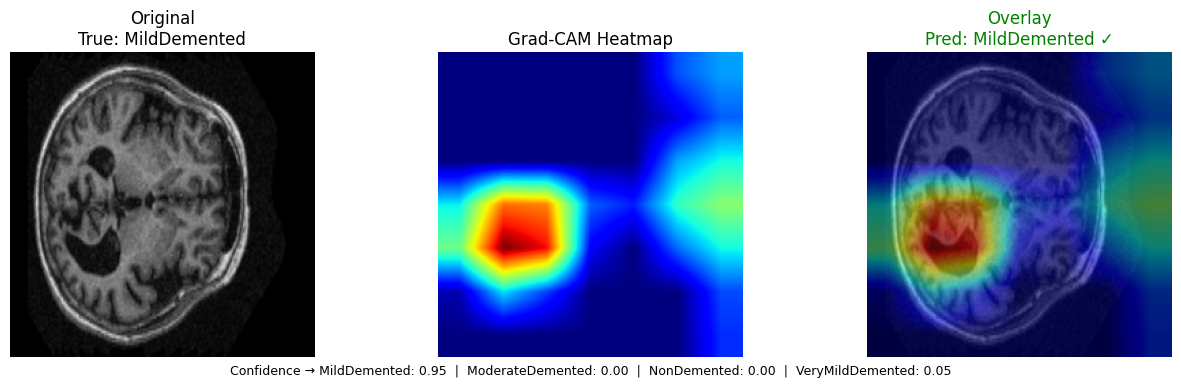

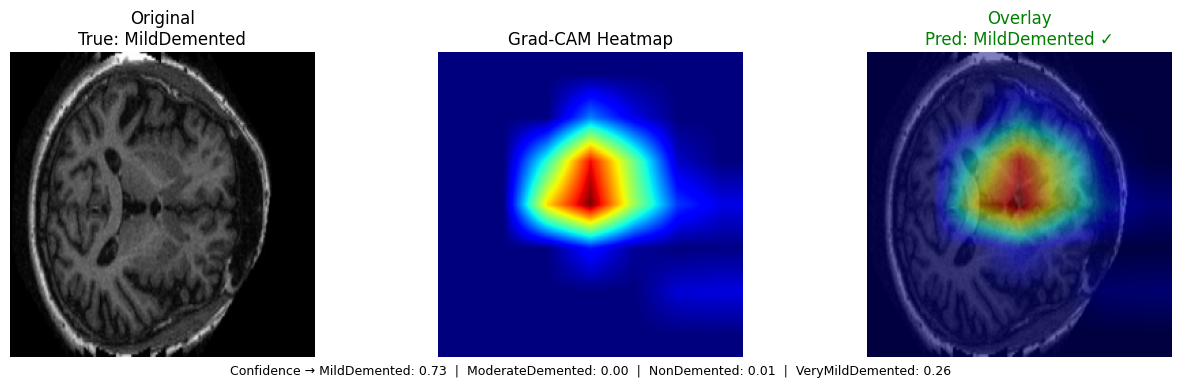


Class: ModerateDemented


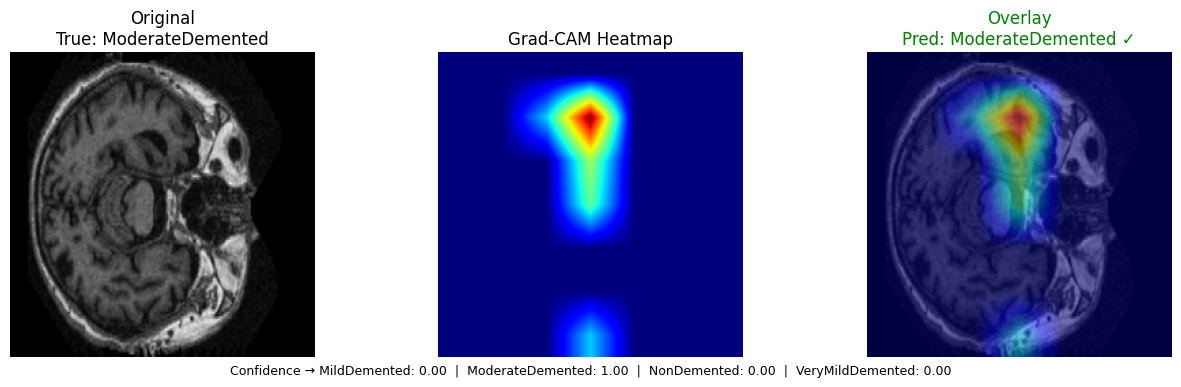

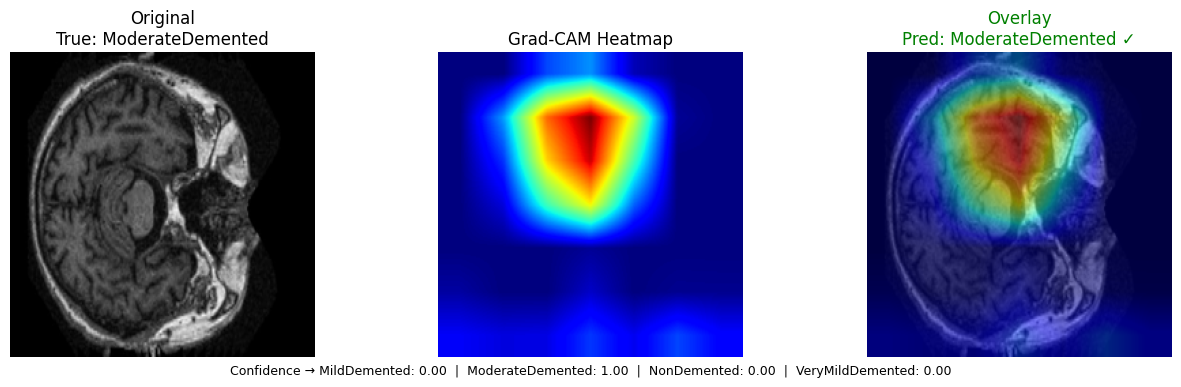


Class: NonDemented


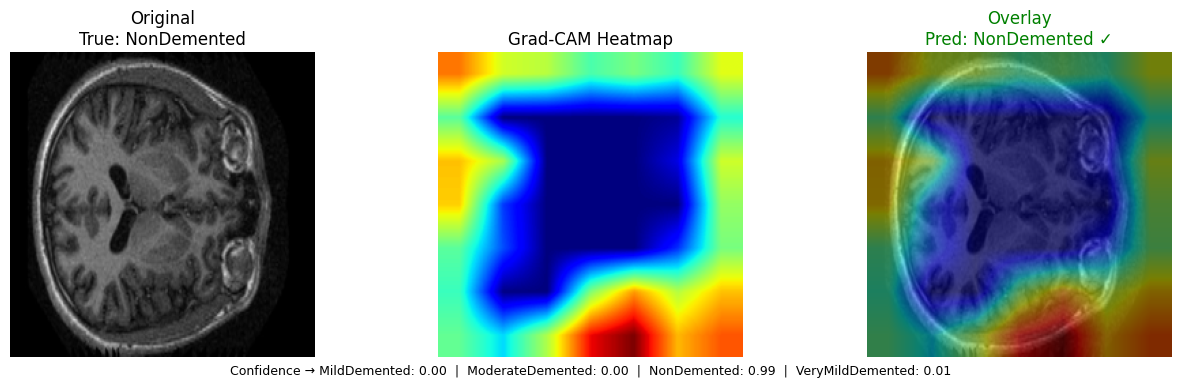

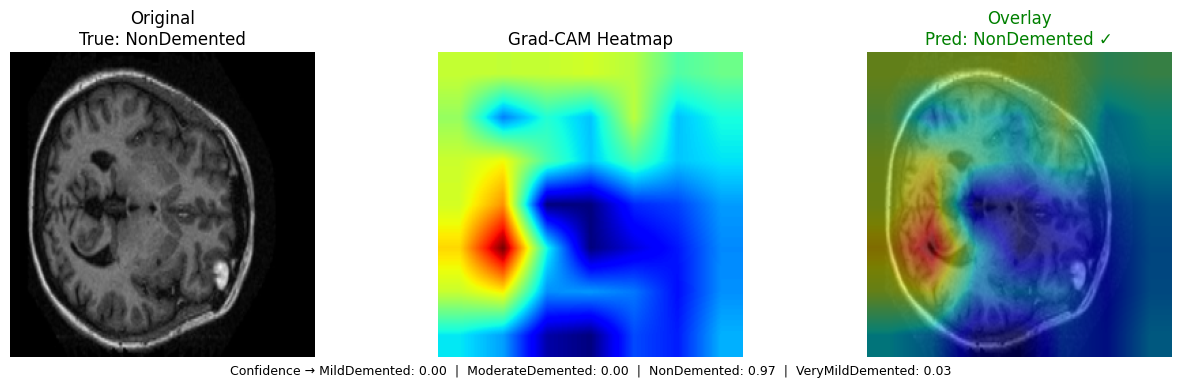


Class: VeryMildDemented


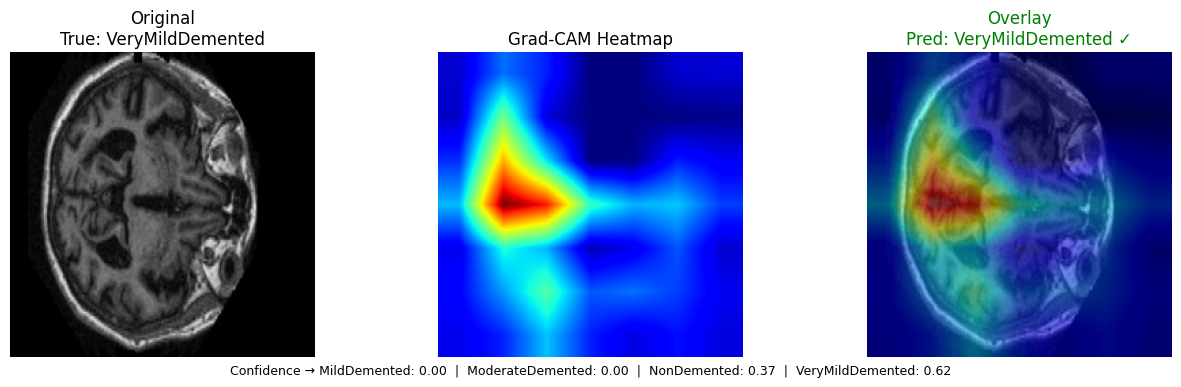

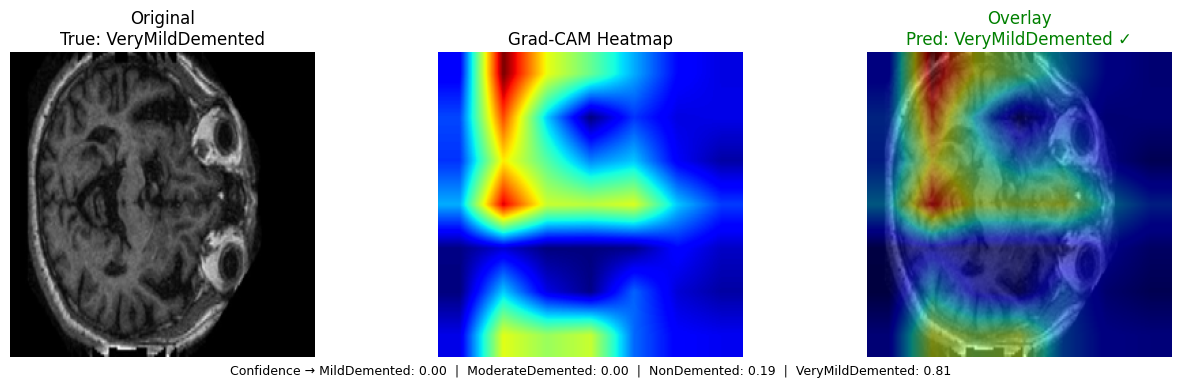

In [5]:
# ========================================
# Grad-CAM (ConvNeXt 전용, channels-last 처리)
# ========================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm

V2_TRAIN_DIR = V2_ROOT / "train"
V2_TRAIN_CSV = V2_ROOT / "train.csv"
SEED = 42

# train_df 재구성 (라벨/슬라이스 정보)
_tr = pd.read_csv(V2_TRAIN_CSV)
def _pid(fn): n=int(fn.replace('train_','').replace('.jpg','')); return (n-1)//SLICES_PER_PATIENT
def _sidx(fn): n=int(fn.replace('train_','').replace('.jpg','')); return (n-1)%SLICES_PER_PATIENT
_tr['slice_idx'] = _tr['filename'].apply(_sidx)
gradcam_df = _tr[(_tr['slice_idx']>=25)&(_tr['slice_idx']<35)].reset_index(drop=True)

def val_tfm():
    return T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.ToTensor(),T.Normalize(MEAN,STD)])


class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        # ConvNeXt 마지막 stage 전체에 hook (LayerNorm 전, conv 출력)
        target_layer = model.stages[-1].blocks[-1].conv_dw
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):
        self.activations = o.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def _to_bchw(self, t):
        # ConvNeXt conv_dw 출력은 (B,C,H,W) 형태. 혹시 (B,H,W,C)면 변환
        if t.dim() == 4 and t.shape[1] != t.shape[3] and t.shape[3] < t.shape[1]:
            return t  # 이미 BCHW
        return t

    def generate(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        pred = out.argmax(1).item()
        if class_idx is None:
            class_idx = pred
        self.model.zero_grad()
        out[0, class_idx].backward()

        grad = self.gradients   # (B,C,H,W)
        act = self.activations  # (B,C,H,W)
        weights = grad.mean(dim=(2,3), keepdim=True)
        cam = (weights * act).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE,IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred, out.softmax(1).detach().cpu().numpy()[0]


def show_gradcam(image_path, true_label, model, alpha=0.5):
    img_pil = Image.open(image_path).convert('RGB')
    x = val_tfm()(img_pil).unsqueeze(0).to(device)
    gc_ = GradCAM(model)
    cam, pred_idx, probs = gc_.generate(x)
    pred_label = IDX2LABEL[pred_idx]
    correct = (pred_label == true_label)

    img_np = np.array(img_pil.resize((IMG_SIZE,IMG_SIZE)))/255.0
    heatmap = cm.jet(cam)[:,:,:3]
    overlay = np.clip(alpha*heatmap + (1-alpha)*img_np, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(13,4))
    bc = 'green' if correct else 'red'
    ax[0].imshow(img_np); ax[0].set_title(f"Original\nTrue: {true_label}"); ax[0].axis('off')
    ax[1].imshow(cam, cmap='jet'); ax[1].set_title("Grad-CAM Heatmap"); ax[1].axis('off')
    ax[2].imshow(overlay)
    ax[2].set_title(f"Overlay\nPred: {pred_label} {'✓' if correct else '✗'}", color=bc)
    ax[2].axis('off')
    prob_str = "  |  ".join([f"{IDX2LABEL[i]}: {probs[i]:.2f}" for i in range(NUM_CLASSES)])
    fig.suptitle(f"Confidence → {prob_str}", fontsize=9, y=0.02)
    for a in ax:
        for s in a.spines.values():
            s.set_edgecolor(bc); s.set_linewidth(2)
    plt.tight_layout(); plt.show()
    return pred_label, correct


def run_gradcam_by_class(model, n_per_class=2):
    for cls in list(LABEL2IDX.keys()):
        s = gradcam_df[gradcam_df['label']==cls].sample(n=n_per_class, random_state=SEED)
        print(f"\n{'='*50}\nClass: {cls}\n{'='*50}")
        for _, row in s.iterrows():
            show_gradcam(V2_TRAIN_DIR/row['filename'], cls, model)


# Final_7 fold 0 모델로 실행
model_gc = build_model()
model_gc.load_state_dict(torch.load(CKPT7/"fold0_best.pt", map_location=device))
model_gc.eval()
run_gradcam_by_class(model_gc, n_per_class=2)